Check Scene Objects:
Objects in scene: ['no-name-1', 'no-name-2', 'Plane']
Radio Materials in scene: ['itu-concrete', 'itu-ceiling_board', 'itu-medium_dry_ground']


<Figure size 800x1000 with 0 Axes>

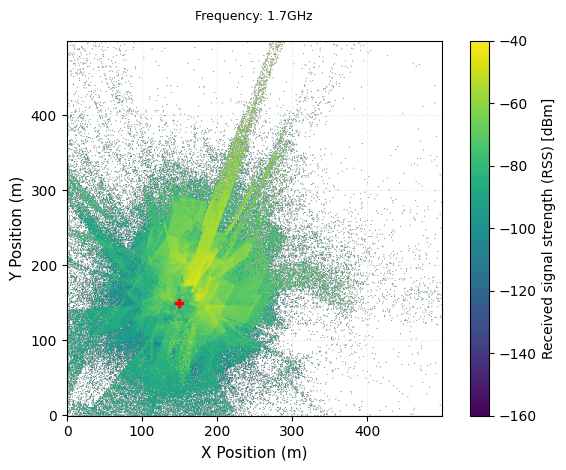

In [1]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver
import matplotlib.pyplot as plt
import pandas as pd

# Import scene from blender mitsuba export (.xml)
scene = load_scene("blender-assets/omori-station.xml")

# Check objects in the scene
print("Check Scene Objects:")
print(f"Objects in scene: {list(scene.objects.keys())}")
print(f"Radio Materials in scene: {list(scene.radio_materials.keys())}")

# Add array for both Tx and Rx to scene
scene.tx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

# Add frequency to scene
carrier_freq = 1.7e9 # In Hz
scene.frequency = carrier_freq

# Deploy Tx and Rx location
tx = Transmitter("tx", [-100, -100, 23], [0, 0,0], power_dbm=18)
tx_power_dbm = tx.power_dbm[0]
rx = Receiver("rx", [100, 100, 1.5], [0, 0, 0])

# Point Tx and Rx towards each other
tx.look_at(rx.position)
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Plot 2D Radio Map
rm_solver = RadioMapSolver()

rm = rm_solver(
    scene,
    max_depth=10,
    samples_per_tx=10**7,
    cell_size=(1, 1),
    center=[0, 0, 0],
    size=[500, 500],
    orientation=[0, 0, 0]
)

plt.figure(figsize=(8, 10))

# Show radio map
rm.show(metric="rss")

plt.title(
    f"Frequency: {carrier_freq/1e9}GHz",
    fontsize=9,
    pad=15
)
plt.xlabel("X Position (m)", fontsize=11)
plt.ylabel("Y Position (m)", fontsize=11)
plt.clim(-160, -40)
plt.grid(
    alpha=0.2,
    linestyle="--"
)
plt.tight_layout()
plt.show()

# # Optional - Scene Preview
# scene.preview()

# Optional - Scene Preview (Radio Map)
rm_solver = RadioMapSolver()

rm = rm_solver(
        scene,
        max_depth=10, # Number of maximum interation allowed per paths
        samples_per_tx=10**7, # Number of rays launch in transmitter
        cell_size=(1, 1),
        center=[0, 0, 0],
        size=[500, 500], # Size of area to simulate (meter)
        orientation=[0, 0, 0]
    )

scene.preview(
    radio_map=rm,

    rm_metric="rss",
    rm_db_scale=True,

    rm_vmax = -40,
    rm_vmin = -160,

    show_devices=True,
    show_orientations=True,

    point_picker=False
)

# # Optional - Scene Preview (Paths)
# p_solver = PathSolver()

# paths = p_solver(
#     scene,
#     max_depth=10,
#     samples_per_src=10**6
# )

# scene.preview(
#     paths=paths,

#     show_devices=True,
#     show_orientations=True,

#     point_picker=False
# )